# Evaluación del modelo LSTM de predicción de bicis

El modelo reproduce paso a paso el pipeline de `lstm_model.py` y evalúa la calidad de las predicciones dejando como **test** los dos últimos registros de una estación elegida aleatoriamente.

Pasos:
1. Seleccionar una estación aleatoria.
2. Cargar los datos históricos de la estación.
3. Separar train (todo lo anterior al antepenúltimo registro) y test (los dos últimos registros).
4. Entrenar la red LSTM únicamente con train.
5. Predecir los horizontes de 5 y 10 minutos y comparar con los valores reales.

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

# Añadir la raíz del proyecto al path para poder importar backend.scripts.*
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from backend.scripts.lstm_model import LSTMbicis, LOOKBACK, HORIZONTES_MIN, STEP_MINUTES, TARGET_COLS
from backend.scripts.silver.db_config import get_sqlalchemy_url


## 1. Reproducibilidad

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
# Para TensorFlow (opcional, si quieres reproducibilidad total):
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
except Exception:
    pass

print(f"LOOKBACK={LOOKBACK} pasos ({LOOKBACK*STEP_MINUTES} min)" )
print(f"Horizontes: {HORIZONTES_MIN} minutos")
print(f"Targets: {TARGET_COLS}")

LOOKBACK=24 pasos (120 min)
Horizontes: (5, 10) minutos
Targets: ['nbm', 'nbe']


## 2. Selección aleatoria de una estación

Se consultan los identificadores de estación disponibles en la tabla `estado`. Si la consulta falla (por ejemplo, porque no hay conexión a la BD), se usa una lista de respaldo.

In [3]:
def elegir_estacion_aleatoria():
    try:
        from sqlalchemy import create_engine
        engine = create_engine(get_sqlalchemy_url())
        with engine.connect() as conn:
            df_ids = pd.read_sql('''SELECT station_id 
                                    FROM informacion 
                                    WHERE station_id <> 588 
                                    ORDER BY station_id''', conn)
        ids = df_ids['station_id'].astype(int).tolist()
        if not ids:
            raise ValueError("No hay estaciones en la base de datos")
    except Exception as exc:
        print(f"⚠️ No se pudo consultar la BD ({exc}). Usando lista de respaldo.")
        ids = list(range(1, 521))  # rango típico del Bicing
    
    rng = np.random.default_rng()
    return int(rng.choice(ids))

station_id = elegir_estacion_aleatoria()
print(f"Estación seleccionada aleatoriamente: {station_id}")

Estación seleccionada aleatoriamente: 475


## 3. Carga de datos de la estación

Usamos la función `bicis()` de `backend/scripts/gold/bikes.py`, que ya une estado, clima y festivos y rellena huecos a frecuencia de 5 minutos.

In [4]:
bicis = LSTMbicis._import_bicis()
df = bicis(station_id=station_id)
df = df.sort_index()

print(f"Filas totales: {len(df)}")
print(f"Rango temporal: {df.index.min()} -> {df.index.max()}")
print("\nÚltimas filas:")
display(df.tail(5))

Filas totales: 499367
Rango temporal: 2021-01-01 00:02:03 -> 2025-09-30 21:52:03

Últimas filas:


,nbm,nbe,lag_nbm,lag_nbe,hour_sin,hour_cos,dow_sin,dow_cos,year_sin,year_cos,is_holiday,temperature_c,relative_humidity_2m,rain,cloud_cover,wind_speed_10m,is_imputed
datetime,,,,,,,,,,,,,,,,,
2025-09-30 21:32:03,0,14,0.0,14.0,-0.6157,0.7880,0.4339,-0.901,-0.9999,-0.0129,False,19.7,84,0.0,14,0.7,True
2025-09-30 21:37:03,0,13,0.0,14.0,-0.5948,0.8039,0.4339,-0.901,-0.9999,-0.0129,False,19.7,84,0.0,14,0.7,True
2025-09-30 21:42:03,0,13,0.0,13.0,-0.5842,0.8116,0.4339,-0.901,-0.9999,-0.0129,False,19.7,84,0.0,14,0.7,True
2025-09-30 21:47:03,0,14,0.0,13.0,-0.5628,0.8266,0.4339,-0.901,-0.9999,-0.0129,False,19.7,84,0.0,14,0.7,True
2025-09-30 21:52:03,0,14,0.0,14.0,-0.5410,0.8410,0.4339,-0.901,-0.9999,-0.0129,False,19.7,84,0.0,14,0.7,True


## 4. División temporal: train / test

- **train**: todos los registros anteriores a los dos últimos (es decir, hasta el antepenúltimo, índice `-3`).
- **test**: los dos últimos registros (índices `-2` y `-1`), que corresponden a los horizontes de +5 y +10 minutos respectivamente.

In [5]:
min_train_len = LOOKBACK + max(h // STEP_MINUTES for h in HORIZONTES_MIN) + 1
if len(df) < min_train_len + 2:
    raise ValueError(
        f"La estación {station_id} tiene muy pocos registros ({len(df)}) "
        f"para el lookback {LOOKBACK} y los horizontes {HORIZONTES_MIN}."
    )

train_df = df.iloc[:-2].copy()
test_df = df.iloc[-2:].copy()

cutoff = train_df.index[-1]
print(f"Corte train/test: {cutoff}")
print(f"Train: {len(train_df)} filas ({train_df.index.min()} -> {train_df.index.max()})")
print(f"Test:  {len(test_df)} filas ({test_df.index.min()} -> {test_df.index.max()})")

print("\nValores reales en test:")
display(test_df[TARGET_COLS])

Corte train/test: 2025-09-30 21:42:03
Train: 499365 filas (2021-01-01 00:02:03 -> 2025-09-30 21:42:03)
Test:  2 filas (2025-09-30 21:47:03 -> 2025-09-30 21:52:03)

Valores reales en test:


,nbm,nbe
datetime,,
2025-09-30 21:47:03,0,14
2025-09-30 21:52:03,0,14


## 5. Preparación de features y targets

Reutilizamos `preparar_datos` de `LSTMbicis`. Los escaladores se ajustan **únicamente** con train para evitar fugas de información.

In [6]:
modelo = LSTMbicis(station_id=station_id)

df_features_train, feature_cols = modelo.preparar_datos(train_df)
df_features_test, _ = modelo.preparar_datos(test_df)

targets_train = train_df[TARGET_COLS].astype(float)
targets_test = test_df[TARGET_COLS].astype(float)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_x.fit(df_features_train)
scaler_y.fit(targets_train)

features_train_scaled = scaler_x.transform(df_features_train)
features_test_scaled = scaler_x.transform(df_features_test)
targets_train_scaled = scaler_y.transform(targets_train)

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Escaladores ajustados con {len(df_features_train)} filas de train")

Features (15): ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'year_sin', 'year_cos', 'lag_nbm', 'lag_nbe', 'temperature_c', 'relative_humidity_2m', 'rain', 'cloud_cover', 'wind_speed_10m', 'is_holiday', 'is_imputed']
Escaladores ajustados con 499365 filas de train


## 6. Construcción de secuencias de entrenamiento

Cada secuencia de entrada tiene `LOOKBACK` pasos y la salida contiene los valores de `nbm` y `nbe` a 5 y 10 minutos vista.
Separación interna train/val (90/10 cronológico) para el *early stopping*.

In [7]:
horizon_steps = [h // STEP_MINUTES for h in HORIZONTES_MIN]
max_h = max(horizon_steps)

X, y = LSTMbicis.construir_secuencias(
    features_train_scaled,
    targets_train_scaled,
    LOOKBACK,
    horizon_steps,
)

# División temporal interna: 90% train, 10% validación para early stopping
n_val = max(int(len(X) * 0.1), 1)
n_train = len(X) - n_val

X_train, X_val = X[:n_train], X[n_train:]
y_train, y_val = y[:n_train], y[n_train:]

print(f"Secuencias totales: {len(X)}")
print(f"Train: {len(X_train)} | Val: {len(X_val)}")
print(f"Forma X_train: {X_train.shape}, y_train: {y_train.shape}")

Secuencias totales: 499340
Train: 449406 | Val: 49934
Forma X_train: (449406, 24, 15), y_train: (449406, 4)


## 7. Entrenamiento del modelo LSTM

In [8]:
model = LSTMbicis.construir_modelo(
    input_shape=(LOOKBACK, X.shape[2]),
    n_outputs=y.shape[1],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1,
)

print(f"\nEpochs entrenados: {len(history.history['loss'])}")

Epoch 1/5
7022/7022 ━━━━━━━━━━━━━━━━━━━━ 72s 10ms/step - loss: 0.0027 - mae: 0.0332 - val_loss: 0.0017 - val_mae: 0.0271
Epoch 2/5
7022/7022 ━━━━━━━━━━━━━━━━━━━━ 70s 10ms/step - loss: 0.0019 - mae: 0.0264 - val_loss: 0.0023 - val_mae: 0.0312
Epoch 3/5
7022/7022 ━━━━━━━━━━━━━━━━━━━━ 70s 10ms/step - loss: 0.0018 - mae: 0.0252 - val_loss: 0.0024 - val_mae: 0.0324
Epoch 4/5
7022/7022 ━━━━━━━━━━━━━━━━━━━━ 70s 10ms/step - loss: 0.0018 - mae: 0.0246 - val_loss: 0.0024 - val_mae: 0.0320
Epoch 5/5
7022/7022 ━━━━━━━━━━━━━━━━━━━━ 70s 10ms/step - loss: 0.0017 - mae: 0.0242 - val_loss: 0.0025 - val_mae: 0.0322

Epochs entrenados: 5


## 8. Predicción sobre el conjunto de test

Tomamos la última ventana de 24 pasos del train y predecimos los dos siguientes pasos (+5 min y +10 min). Esas predicciones se comparan directamente con los dos registros reales del test.

In [9]:
ultima_ventana = features_train_scaled[-LOOKBACK:].reshape(1, LOOKBACK, X.shape[2])
pred_scaled = model.predict(ultima_ventana, verbose=0)[0]

n_targets = len(TARGET_COLS)
n_horizons = len(horizon_steps)
pred_matrix_scaled = pred_scaled.reshape(n_horizons, n_targets)
pred_matrix = scaler_y.inverse_transform(pred_matrix_scaled)
pred_matrix = np.maximum(pred_matrix, 0)  # las disponibilidades no pueden ser negativas

y_true_matrix = targets_test.values  # (2 horizontes, 2 targets)

resultados = pd.DataFrame(
    {
        "horizonte_min": HORIZONTES_MIN,
        "timestamp_real": [test_df.index[i].isoformat() for i in range(len(test_df))],
    }
)
for j, col in enumerate(TARGET_COLS):
    resultados[f"{col}_real"] = y_true_matrix[:, j]
    resultados[f"{col}_pred"] = pred_matrix[:, j]
    resultados[f"{col}_error"] = np.abs(y_true_matrix[:, j] - pred_matrix[:, j])

display(resultados)

,horizonte_min,timestamp_real,nbm_real,nbm_pred,nbm_error,nbe_real,nbe_pred,nbe_error
0,5,2025-09-30T21:47:03,0.0,0.260705,0.260705,14.0,12.342804,1.657196
1,10,2025-09-30T21:52:03,0.0,0.326576,0.326576,14.0,12.361373,1.638627


## 9. Visualización: real vs predicho

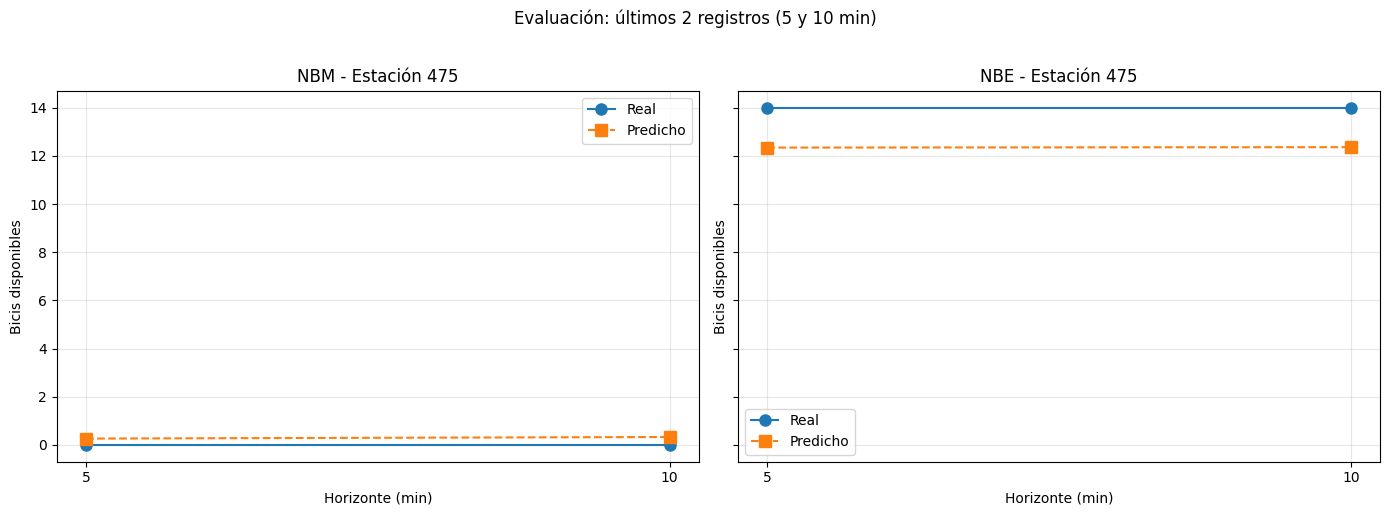

In [10]:
fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(14, 5), sharey=True)
if len(TARGET_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, TARGET_COLS):
    ax.plot(HORIZONTES_MIN, y_true_matrix[:, TARGET_COLS.index(col)], "o-", label="Real", markersize=8)
    ax.plot(HORIZONTES_MIN, pred_matrix[:, TARGET_COLS.index(col)], "s--", label="Predicho", markersize=8)
    ax.set_title(f"{col.upper()} - Estación {station_id}")
    ax.set_xlabel("Horizonte (min)")
    ax.set_ylabel("Bicis disponibles")
    ax.set_xticks(HORIZONTES_MIN)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Evaluación: últimos 2 registros (5 y 10 min)", y=1.02)
plt.tight_layout()
plt.show()